Nome: Paulo Santos do Nascimento Filho

RA: 186629 

Curso: Engenharia de Computação (AB) - 34

#### Projeto de PI - Parte 2 - Análise dos Efeitos ####

 #### 1) Preparação de Dados e Importação de Bibliotecas

In [ ]:
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

# 1. Definir as transformações (Data Augmentation e normalização)
# É realizado um redimensionamento de todas as imagens para o mesmo tamanho para passar na rede neural
transform = transforms.Compose([
    transforms.Resize((128, 128)), # Redimensiona todas as fotos
    transforms.RandomHorizontalFlip(), # Augmentação: espelha aleatoriamente
    transforms.ToTensor(), # Converte para tensor (0 a 1)
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # Normaliza
])

# 2. Carregar o dataset da pasta 'photos'
dataset = datasets.ImageFolder(root='./photos/dataset', transform=transform)

# 3. Separar em Treino e Teste (80% treino, 20% teste)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# 4. Criar os DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Visualizar as classes que o ImageFolder encontrou
classes = dataset.classes
print(f"Efeitos encontrados: {classes}")

Efeitos encontrados: ['175807_futuro', '175807_maria_e_sobel', '175807_pixelular', '186629_canny_edge_detection', '186629_chromatic_aberration_blur', '186629_color_splash', '237310_aberracao_cromatica', '237310_pixelizacao', '237310_quantizacao', '241163_chromatic_aberration', '241163_edge_detection', '241163_pixelation', '243360_chromatic_aberration', '243360_edge_detection', '243360_radial_blur', '245609_borda_lapis', '245609_fisheye', '245609_onda_de_calor', '245760_aberracao_cromatica', '245760_deteccao_borda', '245760_dithering', '246955_color_mapping', '246955_fish_eye', '246955_restricted_chromatic_aberration_and_vignette', '247145_border_detection', '247145_color_selection', '247145_twirl', '257234_blueprint_effect', '257234_gloomy_effect', '257234_industrial_effect', '260382_delete_later', '260382_difference_of_gaussians_flow', '260382_difference_of_gaussians_flow_less', '260382_dithering_black_white', '260382_dithering_red_black_white', '260382_dithering_red_yellow_black_whit

#### 2) Exploração Inicial (Visualização)

Visualização de imagens e funcionamento do dataloader:

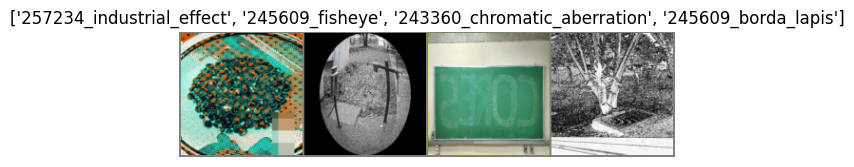

In [12]:
def imshow(img, title):
    img = img / 2 + 0.5     # desnormaliza
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')
    plt.show()

# Pega um batch de imagens de treino
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Mostra as primeiras 4 imagens do batch
imshow(torchvision.utils.make_grid(images[:4]), title=[classes[x] for x in labels[:4]])

#### 3) Modelo Supervisionado (Classificação dos Efeitos)

Utilização de uma Rede Neural Convulucional (CNN).

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Definindo uma CNN Simples
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 32 * 32, 128) # Depende do tamanho da imagem (128x128 -> 32x32 após 2 pools)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 32 * 32) # Achata (Flatten)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instancia modelo, loss e otimizador
model = SimpleCNN(num_classes=len(classes))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Loop de Treinamento (5 épocas)
epochs = 5
for epoch in range(epochs):
    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f'Época {epoch+1}, Loss: {running_loss/len(train_loader)}')
print("Treino Finalizado!")

Época 1, Loss: 2.304091385609128
Época 2, Loss: 1.451508179229776
Época 3, Loss: 1.1158971933194393
Época 4, Loss: 0.849160290487265
Época 5, Loss: 0.7218345232269306
Treino Finalizado!


#### 4) Geração matriz para visualização acerto de dados

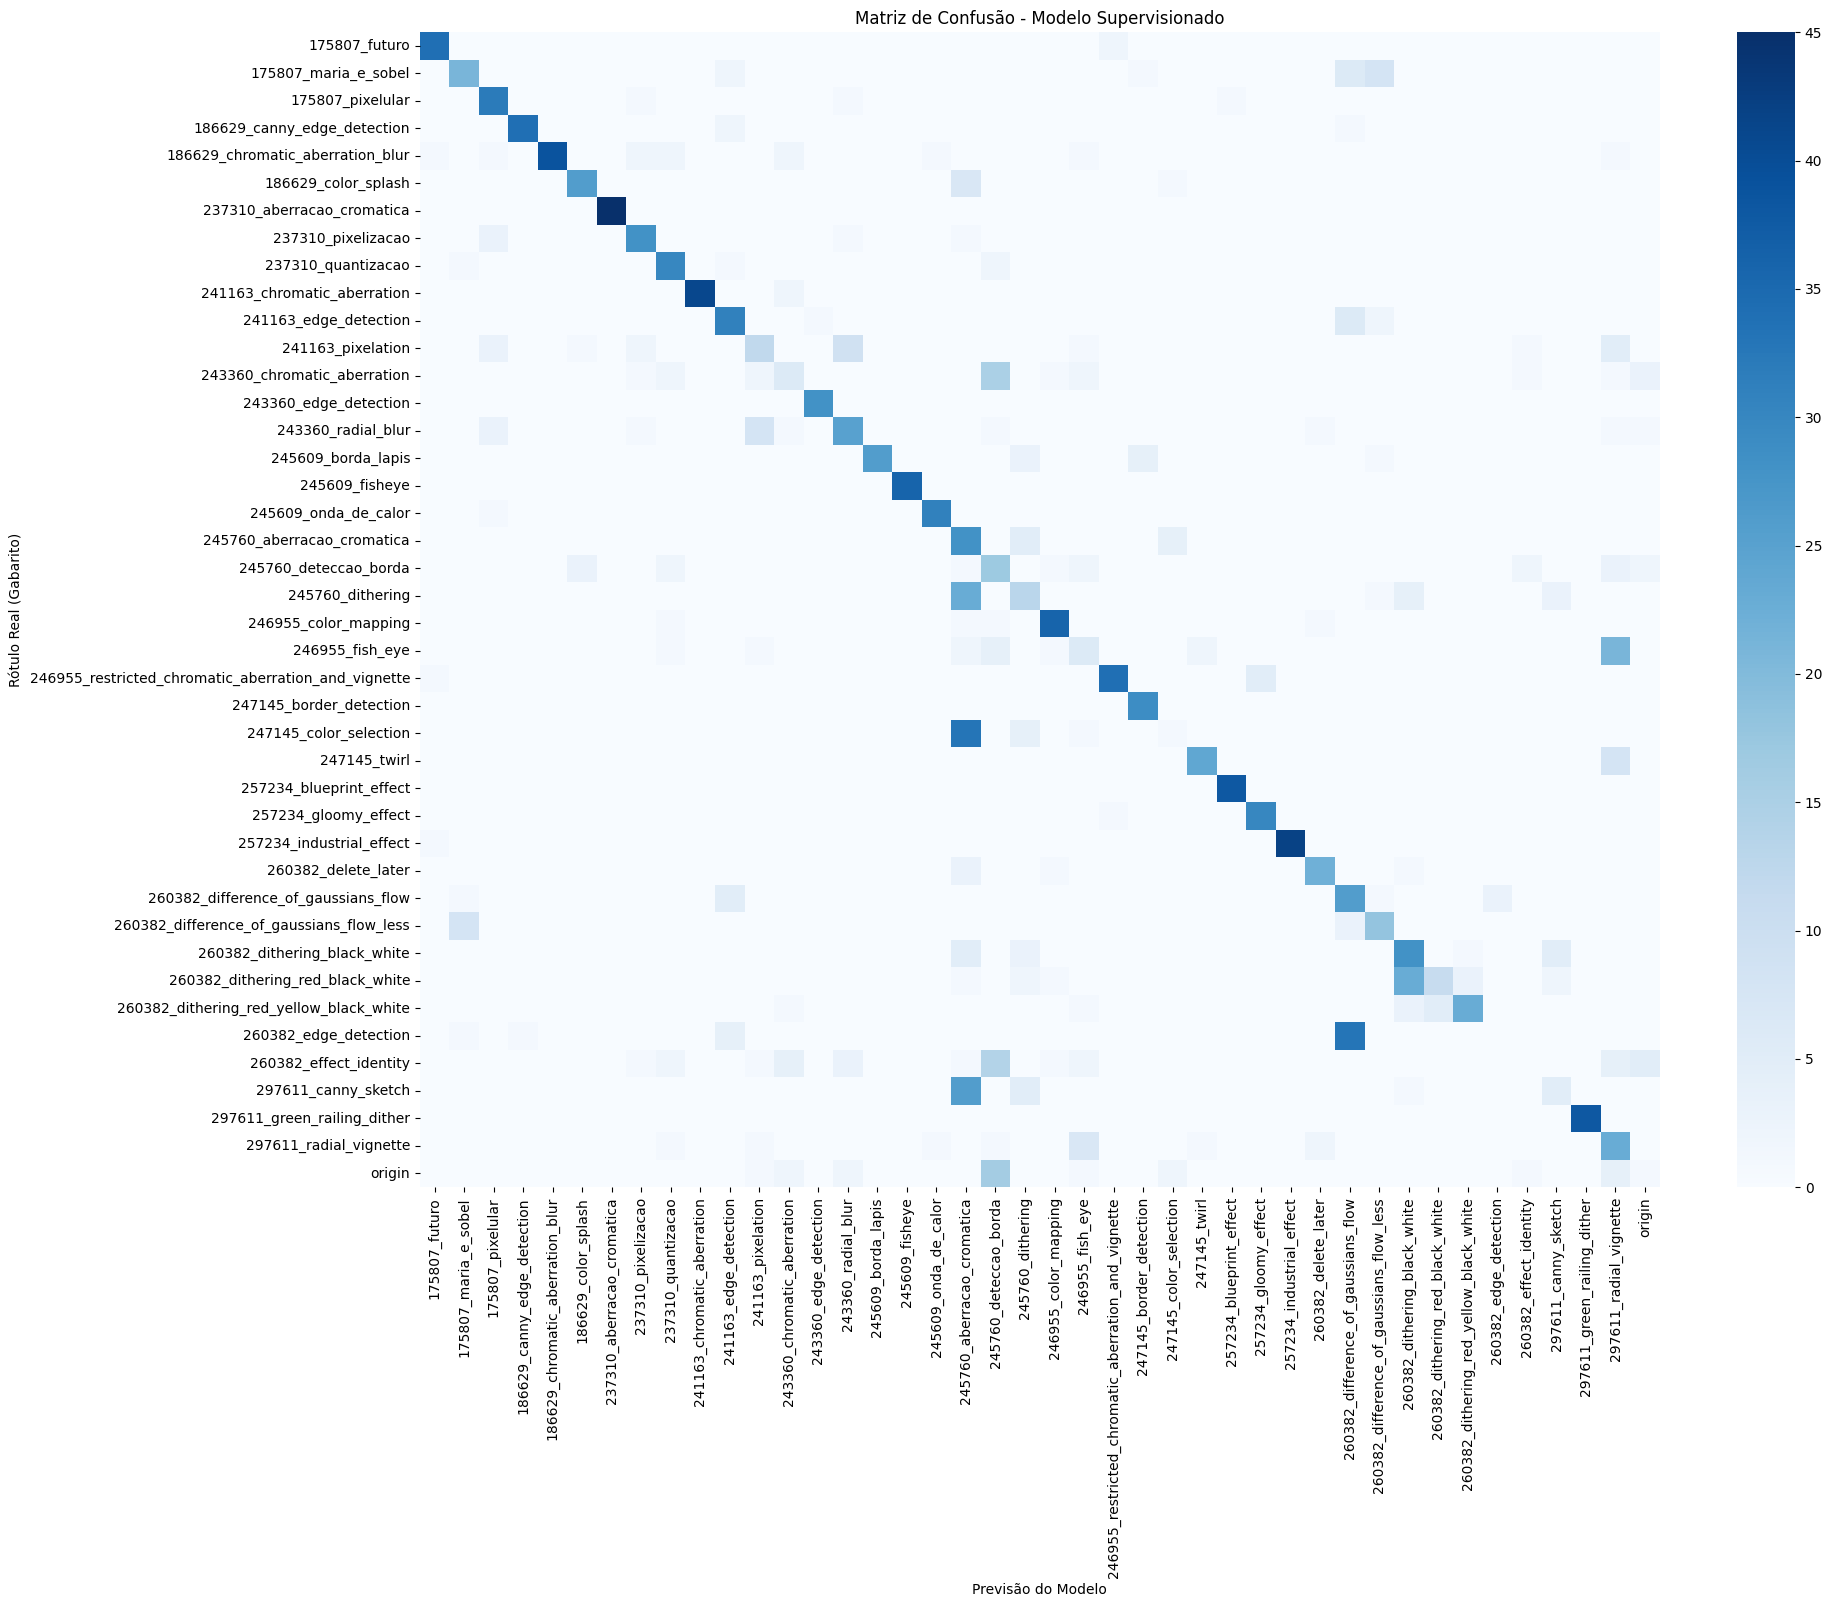

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Pega todas as imagens de TESTE (que o modelo não viu no treino)
all_preds = []
all_labels = []

model.eval() # Coloca o modelo em modo de avaliação
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

# Gera a Matriz de Confusão
cm = confusion_matrix(all_labels, all_preds)

# Plota matriz de visualização acerto dos dados e previsão do modelo
plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusão - Modelo Supervisionado')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Rótulo Real (Gabarito)')
plt.show()

> _Matriz que avalia o desempenho do modelo comparando as predições feitas pela rede (eixo X) com o gabarito real das imagens (eixo Y). A linha diagonal evidencia os acertos exatos da rede (escuro ao claro), enquanto os pontos fora da diagonal indicam onde o modelo se confundiu (geralmente entre efeitos visualmente semelhantes ou muito sutis)._

*Obs: com relação ao número de épocas de treinamento, o valor de 5 foi definido como um parâmetro experimental; se este valor for incrementado demasiadamente, a rede corre o risco de sofrer overfitting (sobreajuste), passando a apenas memorizar as fotos de treino ao invés de aprender as características gerais de cada filtro.*

#### 5) Modelo Não Supervisionado (PCA e KNN/K-Means)

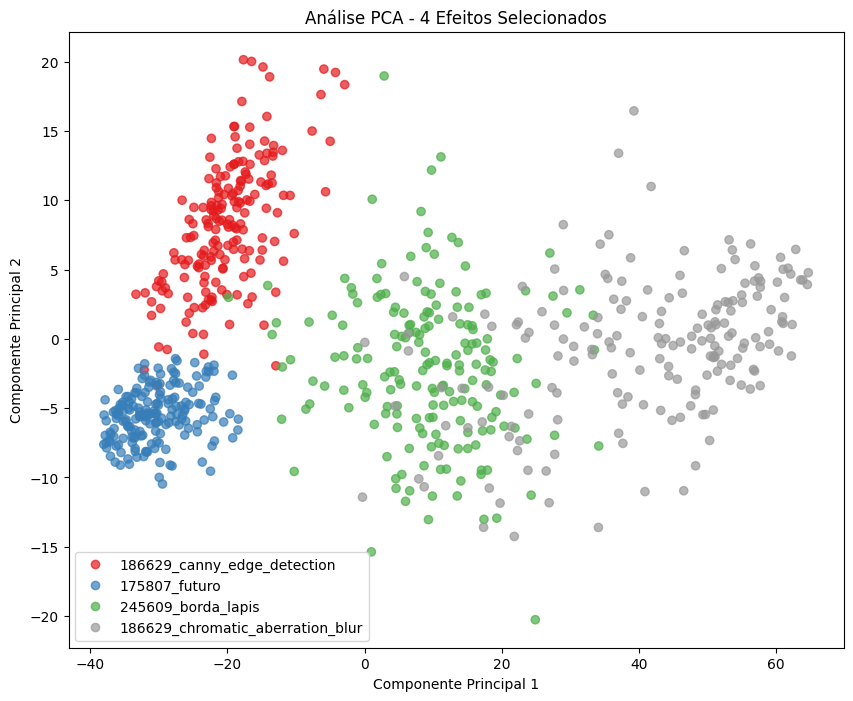

In [ ]:
import os
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset

import torchvision.transforms as transforms
from sklearn.decomposition import PCA

# Criação do transformador PCA
pca_transform = transforms.Compose([
    transforms.Resize((64, 64)), 
    transforms.ToTensor()
])

# Feito o carregamento do dataset
pca_dataset = datasets.ImageFolder(root='./photos/dataset', transform=pca_transform)

# 1. Escolhida 4 classes aleatórias do conjunto de classes
classes_escolhidas = [
    '186629_canny_edge_detection', 
    '175807_futuro', 
    '245609_borda_lapis',
    '186629_chromatic_aberration_blur'
]

# 2. Descobre os índices numéricos das classes
indices_das_classes = [pca_dataset.class_to_idx[c] for c in classes_escolhidas]

# 3. Filtra o dataset para pegar somente as imagens dessas 4 classes
indices_filtrados = [i for i, (_, label) in enumerate(pca_dataset) if label in indices_das_classes]
dataset_filtrado = Subset(pca_dataset, indices_filtrados)

# 4. Cria um novo DataLoader somento com essas imagens
loader_filtrado = DataLoader(dataset_filtrado, batch_size=len(dataset_filtrado), shuffle=False)

# 5. Extrai e aplica o PCA
images_pca, labels_pca = next(iter(loader_filtrado))
images_flat = images_pca.view(images_pca.shape[0], -1).numpy()

pca = PCA(n_components=2)
components = pca.fit_transform(images_flat)

# 6. Plota um novo gráfico
plt.figure(figsize=(10, 8))
scatter = plt.scatter(components[:, 0], components[:, 1], c=labels_pca.numpy(), cmap='Set1', alpha=0.7)

# Arruma a legenda
plt.legend(handles=scatter.legend_elements()[0], labels=classes_escolhidas)
plt.title('Análise PCA - 4 Efeitos Selecionados')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

### Discussão e Análise dos Resultados

Nesta etapa, exploramos o dataset aplicando duas abordagens distintas de Aprendizado de Máquina: uma supervisionada (Rede Neural Convolucional - CNN) e uma não-supervisionada (Análise de Componentes Principais - PCA). O objetivo não era apenas obter alta precisão, mas entender o comportamento dos dados e como as transformações (efeitos) os afetam matematicamente.

#### 1. Análise do Modelo Supervisionado (CNN)
**O modelo performa bem ou mal? Por quê?**
O modelo supervisionado obteve um ótimo desempenho. Isso é evidenciado inicialmente pela curva de *Loss* (Erro), que caiu consistentemente de 2.30 na primeira época para 0.72 na quinta época, demonstrando que a rede conseguiu extrair características relevantes dos pixels para diferenciar os efeitos. 

Além disso, ao observarmos a Matriz de Confusão, notamos uma forte e escura linha na diagonal principal. Isso significa que, para a grande maioria das imagens do conjunto de teste, a previsão do modelo coincidiu com o rótulo real (gabarito).

**Existem grupos de fotos que ele classifica de forma errada? Por que isto acontece?**
Sim. A análise dos erros (os quadrados fora da diagonal principal) nos traz os insights mais importantes sobre o dataset:
*   **Confusão entre efeitos da mesma "família":** O modelo se confunde ao tentar classificar efeitos que têm propósitos visuais semelhantes. Por exemplo, efeitos criados por equipes diferentes que realizam "detecção de bordas" (como *canny_edge*, *deteccao_borda* ou *edge_detection*) geram matrizes de pixels muito parecidas (fundo escuro com linhas claras). A rede neural identifica o padrão espacial da borda, mas tem dificuldade em dizer de qual pasta exata ele veio, pois visualmente o resultado é quase idêntico.
*   **Confusão com a foto Original (`origin`):** Observando a linha da classe `origin` (fotos sem efeito), vemos leves confusões com efeitos sutis (ex: leves distorções ou aberrações cromáticas). Como esses efeitos alteram muito pouco os valores dos pixels originais, a convolução da rede neural pode não captar a diferença, classificando uma foto original como se tivesse um filtro sutil, ou vice-versa.

#### 2. Análise do Modelo Não-Supervisionado (PCA)
O objetivo do PCA foi reduzir a dimensionalidade dos dados (achatando os pixels) para encontrar padrões de agrupamento naturais, sem informar ao modelo qual era o efeito da foto. Selecionamos 4 classes para essa análise.

**Quais grupos ele agrupa juntos ou separa? Por quê?**
*   **A separação drástica (Vermelho e Azul):** Os efeitos `186629_canny_edge_detection` (vermelho) e `175807_futuro` (azul) formaram *clusters* (grupos) muito bem isolados à esquerda do gráfico. Isso acontece porque esses efeitos são **estruturalmente drásticos**. O *Canny Edge*, por exemplo, remove todas as cores e deixa apenas linhas brancas. Essa mudança na matriz de pixels é tão forte que sobrepõe qualquer característica da foto original. O PCA consegue isolá-los facilmente.
*   **A grande mistura (Verde e Cinza):** Por outro lado, os efeitos `245609_borda_lapis` (verde) e `186629_chromatic_aberration_blur` (cinza) estão completamente misturados à direita do gráfico. Como o PCA avalia os pixels de forma bruta e global, ele dá muito mais peso à "geometria" da foto original (onde é o céu, onde tem sombra) do que ao filtro sutil aplicado. Nesses casos, o algoritmo agrupou as imagens baseado no **conteúdo da foto** (paisagem, retrato), ignorando o efeito.

#### 3. O que esses comportamentos nos dizem sobre os dados? (Conclusão)
A partir dessas análises, extraímos conclusões críticas sobre a modelagem de dados em Visão Computacional:
1.  **A limitação dos pixels crus:** Analisar imagens achatando seus pixels (como feito no PCA) é ineficaz para classificar filtros de cor ou textura, pois o conteúdo original da foto cria um "ruído" matemático maior do que o próprio filtro. Por isso, a extração de características espaciais feita pela CNN (Supervisionada) é muito mais adequada para essa tarefa.
2.  **Possível Viés / Vazamento de Dados (*Data Leakage*):** Como o dataset foi construído aplicando filtros sobre as *mesmas fotos originais*, corremos um risco ético e técnico. Se uma foto específica de um "cachorro" com filtro A for para o Treino, e a foto desse mesmo "cachorro" com filtro B for para o Teste, o modelo pode estar aprendendo a reconhecer o "cachorro" em vez de reconhecer o filtro. Isso explica a alta precisão da rede e nos alerta para a necessidade de separar o dataset por *fotos base*, e não apenas por *efeitos*, em aplicações do mundo real.